In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os.path as op
import os
import pandas as pd

bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk'
bids_folder_orig = '/mnt_03/ds-dnumrisk' 

In [11]:
grad_n ='both2D'
confspec = '32Pscrub3BPfilterrunFD104'
newConf32_NPCdisper = pd.read_csv(op.join(bids_folder_orig, 'derivatives', 'phenotype',f'withinNdispersion-NPC_grad-{grad_n}_confspec-{confspec}.csv' )).set_index('subject').sort_index()
df_neural = newConf32_NPCdisper.rename(columns={'NPC_2D_dispersion': f'NPC_dispersion_32P_2D'})

In [2]:
grad_n = 2

oldConf_NPCdisper = pd.read_csv(op.join(bids_folder_orig, 'derivatives', 'phenotype',f'withinNdispersion-NPC_grad-{grad_n}.csv' )).set_index('subject')

confspec = '32Pscrub3BPfilterrunFD104'
newConf32_NPCdisper = pd.read_csv(op.join(bids_folder_orig, 'derivatives', 'phenotype',f'withinNdispersion-NPC_grad-{grad_n}_confspec-{confspec}.csv' )).set_index('subject').sort_index()

confspec = '36Pscrub3BPfilterrunFD104'
newConf36_NPCdisper = pd.read_csv(op.join(bids_folder_orig, 'derivatives', 'phenotype',f'withinNdispersion-NPC_grad-{grad_n}_confspec-{confspec}.csv' )).set_index('subject').sort_index()
#print(newConf36_NPCdisper.sort_index())

df_neural = pd.concat([newConf36_NPCdisper.rename(columns={'NPC_dispersion': 'NPC_dispersion_36P'})['NPC_dispersion_36P'],
    newConf32_NPCdisper.rename(columns={'NPC_dispersion': 'NPC_dispersion_32P'})['NPC_dispersion_32P']], axis=1)
df_neural.head()

,NPC_dispersion_36P,NPC_dispersion_32P
subject,,
1,2.193481,1.970862
2,2.765502,2.269899
3,2.402229,1.819030
4,12.034594,6.943712
5,4.957668,3.842740


In [3]:
from numrisk.fmri_analysis.gradients.utils_02 import get_all_behavior

df_behav = get_all_behavior(bids_folder_orig)
df_behav.head()

,,gamma,intercept,n1_slope,weber_frac,Percent Correct,weber_frac_log,memory_noise_sd,perceptual_noise_sd,basisscore,overall_score,erfassungsspanne,memory_noise_sd_unbiased,perceptual_noise_sd_unbiased,skill_score,visio-spatial IQ,verbal IQ,mean_iq
subject,group,,,,,,,,,,,,,,,,,
1,0,4.705314,-0.201185,0.025097,0.143232,85.984848,-1.943288,0.128094,0.074870,5,13.0,8,0.115213,0.102558,36.0,120.0,105.0,112.5
2,1,3.425356,0.046009,0.048086,0.119873,88.257576,-2.121318,0.222981,0.052561,5,10.0,6,0.196658,0.122329,6.0,100.0,95.0,97.5
3,0,2.933502,-0.153413,0.032216,0.349204,72.348485,-1.052099,0.137517,0.160089,4,7.0,5,0.213540,0.150741,29.0,115.0,95.0,105.0
4,1,4.930412,-0.136875,0.037974,0.183717,82.196970,-1.694361,0.178991,0.021833,4,7.0,6,0.105920,0.091129,34.0,110.0,105.0,107.5
5,0,3.599923,-0.279398,0.022015,0.154192,84.469697,-1.869560,0.130870,0.126985,4,10.0,7,0.127888,0.153583,30.0,90.0,115.0,102.5


/tmp/ipykernel_2651303/3485982771.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  r_ = np.round(cor['r'][0], 2)
/tmp/ipykernel_2651303/3485982771.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p = np.round(cor['p-val'][0], 3)
/tmp/ipykernel_2651303/3485982771.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  r_ = np.round(cor['r'][0], 2)
/tmp/ipykernel_2651303/3485982771.py:10: FutureWarning: Series.__getitem__ treating 

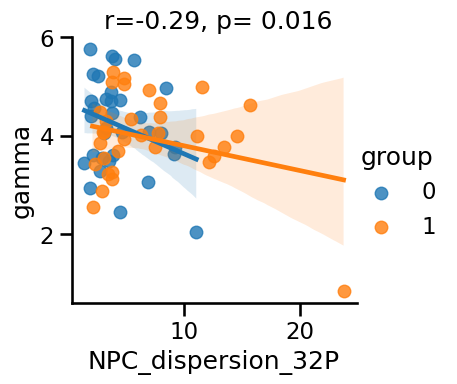

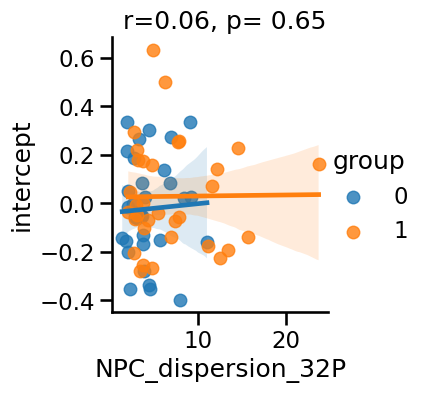

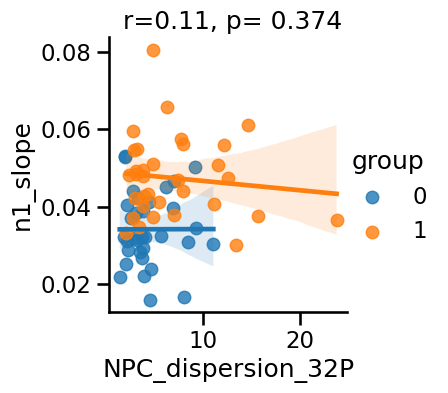

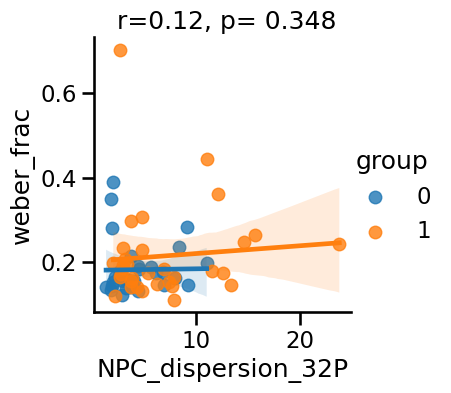

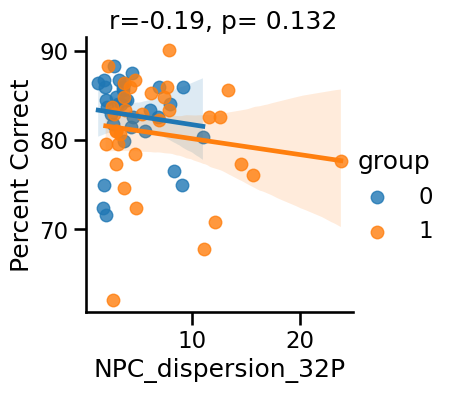

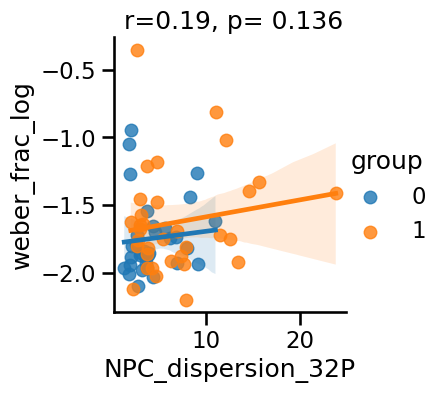

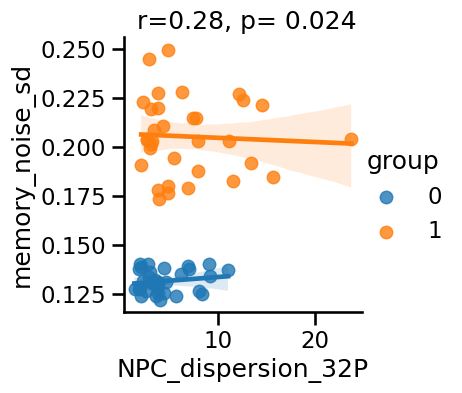

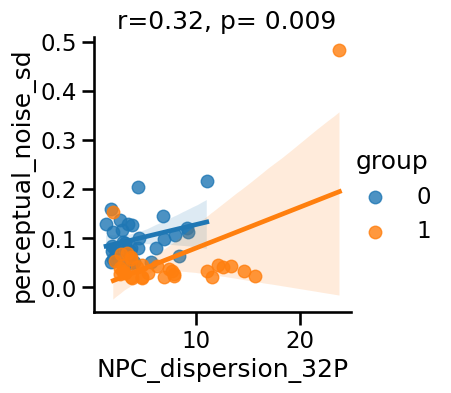

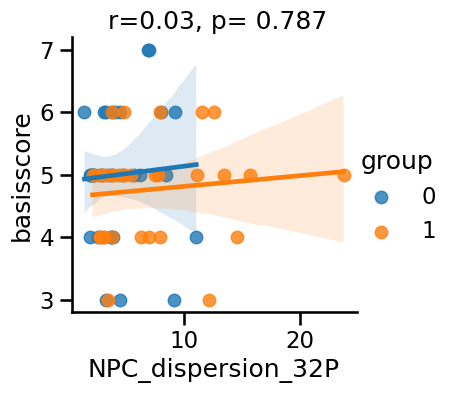

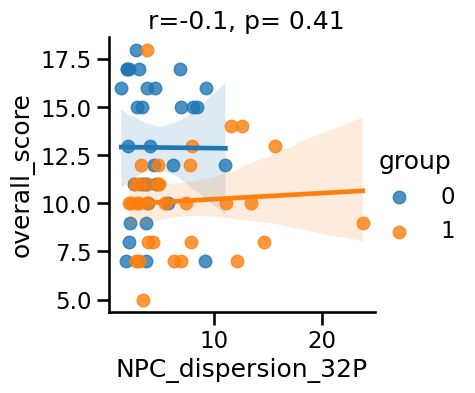

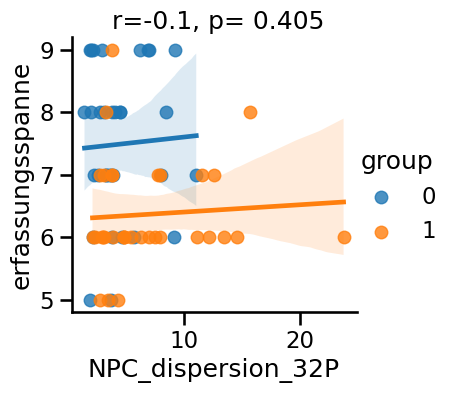

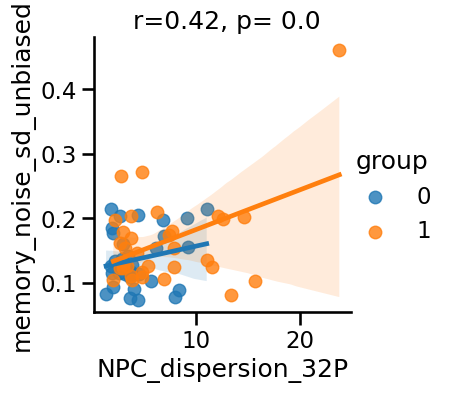

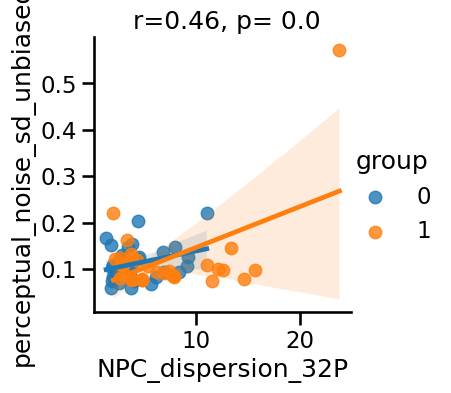

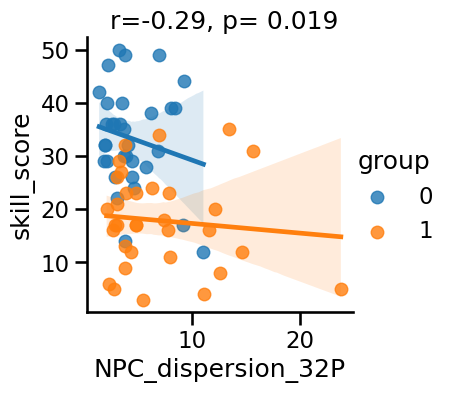

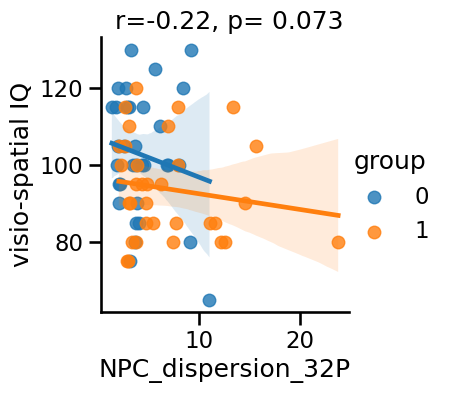

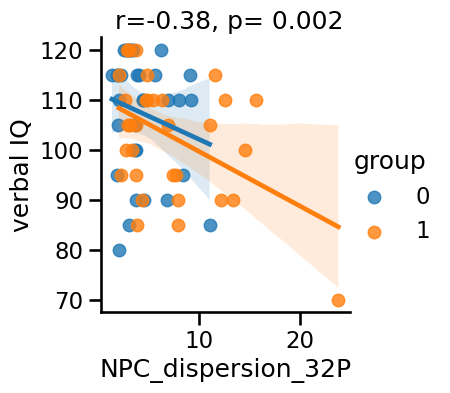

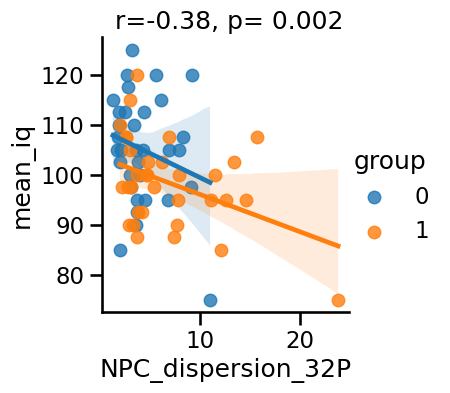

In [5]:
import pingouin
sns.set_context('talk')

df_comb = pd.concat([df_neural, df_behav.reset_index('group')], axis=1)#.drop(6) # .drop(46) .drop(columns=['group'])
neural_var = 'NPC_dispersion_32P'

for behav_var in df_behav.columns.to_list():
    cor = pingouin.corr(df_comb[neural_var], df_comb[behav_var], kind='shepard')
    r_ = np.round(cor['r'][0], 2)
    p = np.round(cor['p-val'][0], 3)
    #print(f'{x_var} vs {y_var}: r={r_}, p= {p}')
    fig = sns.lmplot(data=df_comb, x=neural_var, y=behav_var, hue='group', height=4)  # Use the cleaned dataframe
    fig.set(title=f' r={r_}, p= {p}') 

In [9]:
df_behav.columns.to_list()

['gamma',
 'intercept',
 'n1_slope',
 'weber_frac',
 'Percent Correct',
 'weber_frac_log',
 'memory_noise_sd',
 'perceptual_noise_sd',
 'basisscore',
 'overall_score',
 'erfassungsspanne',
 'memory_noise_sd_unbiased',
 'perceptual_noise_sd_unbiased',
 'skill_score',
 'visio-spatial IQ',
 'verbal IQ',
 'mean_iq']

In [18]:
import statsmodels.api as sm

transform_log = True
z_score = False
neural_var = 'NPC_dispersion_32P'#'NPC_dispersion_36P_2D'
behav_var = 'skill_score'#'visio-spatial IQ' 'perceptual_noise_sd'#'verbal IQ'#

#formula = 'neuralVar ~ behaveVar + group' #+ age'
formula = 'behaveVar ~ neuralVar + group' # + neuralVar:group'

df_comb = pd.concat([df_neural, df_behav.reset_index('group')], axis=1)#.drop(6)#.drop(46) #-- these two make a huge difference... # .drop(columns='group')
tmp = pd.DataFrame()
tmp['neuralVar'] = df_comb[neural_var]
tmp['behaveVar'] = df_comb[behav_var]
tmp['group'] = df_comb['group']

if transform_log:
    tmp['behaveVar'] = np.log(tmp['behaveVar'])
    tmp['neuralVar'] = np.log(tmp['neuralVar'])
if z_score:
    tmp['behaveVar'] = (tmp['behaveVar'] - tmp['behaveVar'].mean()) / tmp['behaveVar'].std()
    tmp['neuralVar'] = (tmp['neuralVar'] - tmp['neuralVar'].mean()) / tmp['neuralVar'].std()

result = sm.formula.ols(formula=formula, data=tmp).fit()
print()
result.summary()




<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              behaveVar   R-squared:                       0.363
Model:                            OLS   Adj. R-squared:                  0.343
Method:                 Least Squares   F-statistic:                     17.94
Date:                Tue, 20 May 2025   Prob (F-statistic):           6.81e-07
Time:                        14:03:54   Log-Likelihood:                -47.685
No. Observations:                  66   AIC:                             101.4
Df Residuals:                      63   BIC:                             107.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.6240      0.167     21.711      0.000       3.290       3.958
neuralVar     -0.1253      0.107     -1.175      0.244      -0.338       0.088
group         -0.6893      0.132     -5.217      0.000      -0.953      -0.425
==============================================================================
Omnibus:                       13.393   Durbin-Watson:                   1.638
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               14.617
Skew:                          -0.973   Prob(JB):                     0.000670
Kurtosis:                       4.236   Cond. No.                         6.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

/tmp/ipykernel_2651303/2772836216.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  r_ = np.round(cor['r'][0], 2)
/tmp/ipykernel_2651303/2772836216.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p = np.round(cor['p-val'][0], 3)


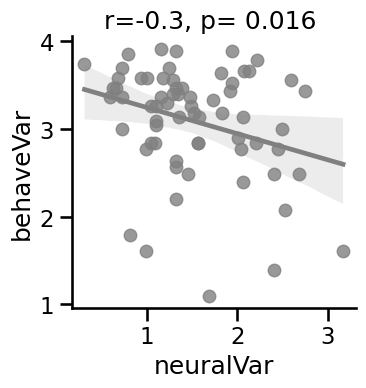

In [19]:
tmp_tmp = tmp
x_var = 'neuralVar'
y_var = 'behaveVar'

cor = pingouin.corr(tmp_tmp[x_var], tmp_tmp[y_var], kind='shepard')
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 3)
fig = sns.lmplot(x=x_var, y=y_var, data=tmp_tmp.reset_index(),height=4,     
    scatter_kws={'color': 'gray'},  # Second color in the palette
    line_kws={'color': 'gray'}     # Second color for the regression line
)
fig.set(title=f'r={r_}, p= {p} ') 

/tmp/ipykernel_2651303/2695649158.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  r_ = np.round(cor['r'][0], 2)
/tmp/ipykernel_2651303/2695649158.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p = np.round(cor['p-val'][0], 3)


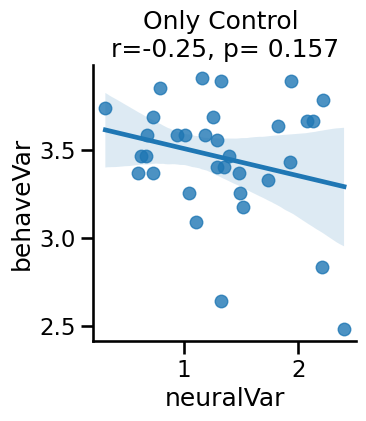

In [23]:
group = 0

tmp_tmp = tmp[tmp['group'] == group]
x_var = 'neuralVar'
y_var = 'behaveVar'

cor = pingouin.corr(tmp_tmp[x_var], tmp_tmp[y_var], kind='shepard')
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 3)
fig = sns.lmplot(x=x_var, y=y_var, data=tmp_tmp.reset_index(),height=4,
    scatter_kws={'color': sns.color_palette()[group]},  # Second color in the palette
    line_kws={'color': sns.color_palette()[group]}     # Second color for the regression line
)
group = 'Dyscalculia' if group == 1 else 'Control'
fig.set(title=f'Only {group} \n r={r_}, p= {p} ') 

/tmp/ipykernel_2651303/1629689685.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  r_ = np.round(cor['r'][0], 2)
/tmp/ipykernel_2651303/1629689685.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p = np.round(cor['p-val'][0], 3)


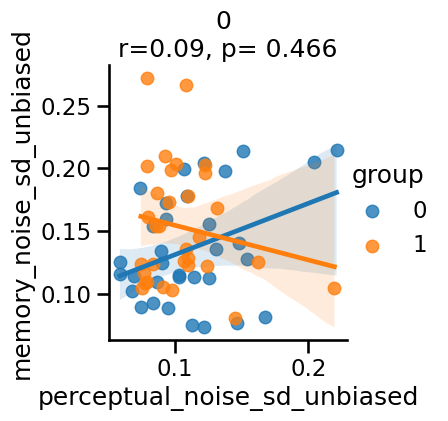

In [21]:
x_var = 'perceptual_noise_sd_unbiased'
y_var = 'memory_noise_sd_unbiased'
group = 0
df_comb = pd.concat([df_neural, df_behav.reset_index('group')], axis=1).drop(46)
df_comb.set_index('group',append=True, inplace=True)
#df_comb = df_comb.xs(group, level='group')

cor = pingouin.corr(df_comb[x_var], df_comb[y_var], kind='shepard')
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 3)
fig = sns.lmplot(x=x_var, y=y_var, data=df_comb.reset_index(),height=4, hue='group') #
fig.set(title=f'{group} \n r={r_}, p= {p} ') 